# **ML(Machine Learning) 기초**
* https://scikit-learn.org/stable/

* <font color=blue> <b> 지도학습(Supervised Learning) </font>: 정답(라벨)이 포함된 데이터를 바탕으로 모델을 훈련시켜 예측이나 분류를 수행하는 방식
* <font color=blue> <b> 비지도 학습(Unsupervised Learning) </font>: 정답이 없는 데이터에서 컴퓨터가 스스로 공통된 특징이나 규칙, 클러스터(군집)를 찾아내는 방식

> 분류(Classification) <br>
> 회귀(Regression) <br>
> 군집(Clustering) <br>

# **[1] Data Load**

In [1]:
from sklearn import set_config
set_config(display="text")          #인코딩 텍스트로 바꿔달라는

In [2]:
import numpy as np
import pandas as pd

In [3]:
df = pd.read_csv("../datas/BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [4]:
df.columns = df.columns.str.upper()   #대문자 변경
df

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


# **[2] 문제지 & 답안지 분리(train_test_split)**

* test_size : 테스트 데이터의 크기 지정 (0~1 사이는 비율 / 1 이상은 데이터 개수)
* train_size : 학습 데이터의 크기 지정 (0~1 사이는 비율 / 1 이상은 데이터 개수)
* random_state : 데이터를 나누는 난수의 기준값 (같은 값 사용 시 항상 같은 방식으로 분할)
* shuffle : 데이터를 분할하기 전에 섞을지 여부, 기본값은 True (시계열 제외)
* stratify : 분류 문제에서 클래스별 비율을 학습/테스트 데이터에 비슷하게 유지

``` python
[default]

sklearn.model_selection.train_test_split(*arrays, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)

## **BostonHousing 활용 : 집값 예측**
* X(문제), y(답)을 7만큼을 학습 → X(문제) 3을 테스트 → 컴퓨터가 낸 예측값(답안지) predict 확인 → y(답) 3만큼을 x3(=predict) 과 비교 후 평가

## **문제지(X) = 집값(MEDV)를 뺀 나머지, 학습할 데이터**

In [5]:
X = df.drop(columns=["MEDV"])
X

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48


## **답안지(y) = 집값(MEDV)**

In [6]:
y = df["MEDV"]
y

0      24.0
1      21.6
2      34.7
3      33.4
4      36.2
       ... 
501    22.4
502    20.6
503    23.9
504    22.0
505    11.9
Name: MEDV, Length: 506, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split
X_train7, X_test3,      y_train7, y_test3 = train_test_split(X, y, test_size=0.3, random_state=1234)             #test_size가 0.3이면 train_size는 자동으로 0.7이됨  ==  비율 3:7

In [8]:
X_train7.shape, X_test3.shape,      y_train7.shape, y_test3.shape

((354, 13), (152, 13), (354,), (152,))

# **모델선택**

``` python
class sklearn.linear_model.LinearRegression(*, fit_intercept=True, copy_X=True, tol=1e-06, n_jobs=None, positive=False)

In [9]:
from sklearn.linear_model import LinearRegression       #회귀모델 (클래스)

In [10]:
lr = LinearRegression()           #생성자함수, 메모리초기화

# **<font color=blue>학습(fit)**

In [11]:
#lr.fit?

In [12]:
lr.fit(X_train7, y_train7)        #학습할 문제지(X) 7, 정답지 라벨 (y=집값) 3  >>> 바로 학습

LinearRegression()

# **<font color=blue>예측(predict)**

In [13]:
#lr.predict?

In [14]:
pred = lr.predict(X_test3)
pred[:10]

array([21.16871632, 24.00813263, 11.98549629, 21.6631808 , 14.18880555,
       27.52381606, 21.37823548, 19.38327949, 27.05874719, 34.35881273])

# **<font color=blue>평가**
* https://scikit-learn.org/stable/modules/model_evaluation.html#mean-squared-error
* https://scikit-learn.org/stable/modules/model_evaluation.html#mean-squared-error

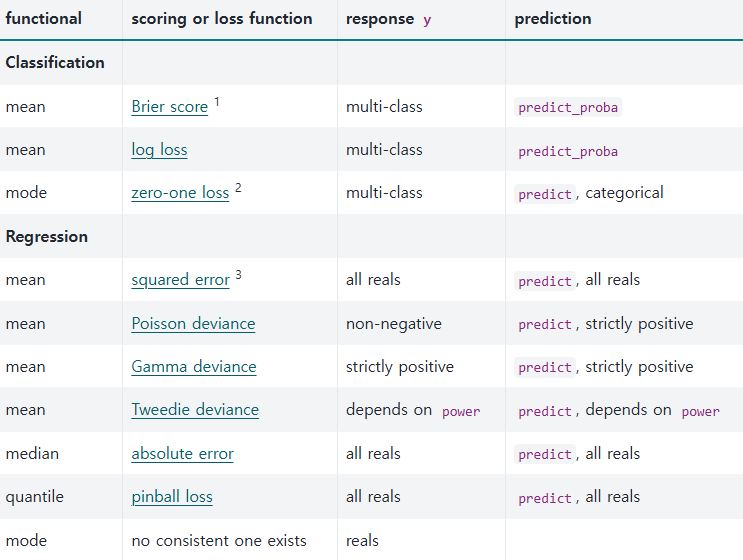

In [15]:
y_test3[:10]

64     33.0
100    27.5
400     5.6
485    21.2
454    14.9
288    22.3
112    18.8
478    14.6
66     19.4
187    32.0
Name: MEDV, dtype: float64

In [16]:
#오차범위

from sklearn.metrics import mean_squared_error      
mse = mean_squared_error(y_test3, pred)         #( 진짜 답, 컴퓨터의 답 )
print( np.sqrt(mse) )                       #np.sqrt : 루트 씌우기

# 평균 오차범위 4.9달러

4.910525893692263
